# Step 5 Modeling - CatBoost

**Created/Updated by:** Angela Johnson

**Goal:** Predict `Depression_Flag` from demographic, socioeconomic, and lifestyle features using CatBoost. `PHQ9_Score` was removed before modeling to prevent target leakage.

1. Loads the pre-built train, validation, and test splits from Step 4.
2. Uses the unencoded categorical dataset prepared specifically for CatBoost.
3. Removes the survey-design and redundant columns used consistently across models.
4. Trains and tunes CatBoost using the validation set.
5. Evaluates the selected model once on the held-out test set.
6. Saves the trained model and performance results for comparison with the other models.

### Files Used

**CatBoost Feature Sets**
- `Nhanes_Cat_Train.csv`
- `Nhanes_Cat_Val.csv`
- `Nhanes_Cat_Test.csv`

**Target Sets**
- `Nhanes_Target_Train.csv`
- `Nhanes_Target_Val.csv`
- `Nhanes_Target_Test.csv`

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from catboost import CatBoostClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    recall_score,
    precision_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Configuration and Data Loading 

In [2]:
# setting project folder paths
BASE_DIR = ".."
SPLIT_DIR = os.path.join(BASE_DIR, "DataSplit")
MODEL_DIR = os.path.join(BASE_DIR, "Models")
FIGURE_DIR = os.path.join(BASE_DIR, "Figures")

# creating output folders if they do not already exist
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# setting random seed for reproducible results
RANDOM_STATE = 42

# defining file name stems for CatBoost features and target data
CAT_STEM = "Nhanes_Cat"
TARGET_STEM = "Nhanes_Target"

In [3]:
# loading CatBoost feature datasets
X_train = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Cat_Train.csv"))
X_val = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Cat_Val.csv"))
X_test = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Cat_Test.csv"))


# loading target datasets
y_train = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Target_Train.csv"))
y_val = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Target_Val.csv"))
y_test = pd.read_csv(os.path.join(SPLIT_DIR, "Nhanes_Target_Test.csv"))


# selecting Depression_Flag as the target variable
y_train = y_train["Depression_Flag"]
y_val = y_val["Depression_Flag"]
y_test = y_test["Depression_Flag"]

# checking the size of the training, validation, and test datasets
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (9611, 23)
X_val: (2060, 23)
X_test: (2060, 23)

y_train: (9611,)
y_val: (2060,)
y_test: (2060,)


In [4]:
# checking feature names and data types
print(X_train.columns.tolist())

print("\nData types:")
print(X_train.dtypes)

['RIAGENDR', 'RIDAGEYR', 'RIDRETH1', 'RIDRETH3', 'RIDEXMON', 'DMDBORN4', 'DMDEDUC2', 'DMDMARTZ', 'INDFMPIR', 'ALQ111', 'ALQ121', 'ALQ130', 'ALQ142', 'ALQ151', 'ALQ170', 'HSQ590', 'INDFMMPI', 'INDFMMPC', 'PAD680', 'SLD012', 'SLD013', 'SMQ020', 'WTMEC_COMB']

Data types:
RIAGENDR      float64
RIDAGEYR      float64
RIDRETH1      float64
RIDRETH3      float64
RIDEXMON      float64
DMDBORN4      float64
DMDEDUC2      float64
DMDMARTZ      float64
INDFMPIR      float64
ALQ111        float64
ALQ121        float64
ALQ130        float64
ALQ142        float64
ALQ151        float64
ALQ170        float64
HSQ590        float64
INDFMMPI      float64
INDFMMPC      float64
PAD680        float64
SLD012        float64
SLD013        float64
SMQ020        float64
WTMEC_COMB    float64
dtype: object


In [5]:
# checking for missing values
print("Missing values in training set:")
print(X_train.isnull().sum())

Missing values in training set:
RIAGENDR      0
RIDAGEYR      0
RIDRETH1      0
RIDRETH3      0
RIDEXMON      0
DMDBORN4      0
DMDEDUC2      0
DMDMARTZ      0
INDFMPIR      0
ALQ111        0
ALQ121        0
ALQ130        0
ALQ142        0
ALQ151        0
ALQ170        0
HSQ590        0
INDFMMPI      0
INDFMMPC      0
PAD680        0
SLD012        0
SLD013        0
SMQ020        0
WTMEC_COMB    0
dtype: int64


In [6]:
# checking the number of unique values in each feature
for col in X_train.columns:
    print(f"{col}: {X_train[col].nunique()} unique values")

RIAGENDR: 2 unique values
RIDAGEYR: 63 unique values
RIDRETH1: 5 unique values
RIDRETH3: 6 unique values
RIDEXMON: 2 unique values
DMDBORN4: 3 unique values
DMDEDUC2: 6 unique values
DMDMARTZ: 4 unique values
INDFMPIR: 490 unique values
ALQ111: 3 unique values
ALQ121: 12 unique values
ALQ130: 14 unique values
ALQ142: 12 unique values
ALQ151: 3 unique values
ALQ170: 22 unique values
HSQ590: 3 unique values
INDFMMPI: 477 unique values
INDFMMPC: 4 unique values
PAD680: 61 unique values
SLD012: 24 unique values
SLD013: 24 unique values
SMQ020: 3 unique values
WTMEC_COMB: 9251 unique values


In [7]:
# viewing a sample of the CatBoost training data
X_train.head()

,RIAGENDR,RIDAGEYR,RIDRETH1,RIDRETH3,RIDEXMON,DMDBORN4,DMDEDUC2,DMDMARTZ,INDFMPIR,ALQ111,ALQ121,ALQ130,ALQ142,ALQ151,ALQ170,HSQ590,INDFMMPI,INDFMMPC,PAD680,SLD012,SLD013,SMQ020,WTMEC_COMB
0,2.0,65.0,3.0,3.0,1.0,2.0,4.0,2.0,2.20,1.0,7.0,1.0,0.0,2.0,0.0,2.0,1.35,2.0,240.0,9.0,9.0,1.0,14503.601935
1,2.0,70.0,3.0,3.0,2.0,1.0,2.0,1.0,3.04,1.0,8.0,2.0,0.0,2.0,0.0,2.0,2.92,3.0,240.0,8.5,8.5,2.0,6581.995746
2,2.0,52.0,5.0,6.0,2.0,2.0,5.0,1.0,5.00,1.0,10.0,1.0,0.0,2.0,0.0,2.0,3.86,3.0,540.0,7.0,9.5,2.0,25030.686924
3,1.0,69.0,4.0,4.0,2.0,1.0,3.0,1.0,5.00,1.0,6.0,3.0,0.0,2.0,0.0,1.0,5.00,3.0,360.0,6.0,8.0,1.0,5470.525489
4,1.0,80.0,3.0,3.0,2.0,1.0,4.0,1.0,2.49,1.0,0.0,2.0,-1.0,2.0,0.0,2.0,2.22,-1.0,480.0,8.5,8.5,2.0,8870.031895


## 2. CatBoost Feature Preparation

In [8]:
# defining categorical features from Step 4 feature engineering
categorical_cols = [
    "RIAGENDR",
    "RIDRETH1",
    "RIDRETH3",
    "RIDEXMON",
    "DMDBORN4",
    "DMDEDUC2",
    "DMDMARTZ",
    "ALQ111",
    "ALQ121",
    "ALQ142",
    "ALQ151",
    "HSQ590",
    "INDFMMPC",
    "SMQ020"
]

In [9]:
# checking categorical feature data types
print(X_train[categorical_cols].dtypes)

RIAGENDR    float64
RIDRETH1    float64
RIDRETH3    float64
RIDEXMON    float64
DMDBORN4    float64
DMDEDUC2    float64
DMDMARTZ    float64
ALQ111      float64
ALQ121      float64
ALQ142      float64
ALQ151      float64
HSQ590      float64
INDFMMPC    float64
SMQ020      float64
dtype: object


## 3. Class Balance 

In [10]:
# checking class balance in each split
for name, y in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(
        f"{name}: n={len(y)}, "
        f"positives={y.sum()}, "
        f"positive rate={y.mean():.4f}"
    )

Train: n=9611, positives=1020, positive rate=0.1061
Val: n=2060, positives=235, positive rate=0.1141
Test: n=2060, positives=235, positive rate=0.1141


> The target variable is imbalanced, with about 10-11% of observations classified as positive for depression across training, validation, and test sets. The similar positive rates across all three datasets indicate that the class distribution was preserved during the data splitting process. And because of this imbalance, model performance will be evaluated using precision, recall, F1-score, ROC-AUC, PR-AUC in addition to accuracy. 

## 4. CatBoost Model Training 

In [11]:
# converting categorical features to strings for CatBoost
for col in categorical_cols:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)
    X_test[col] = X_test[col].astype(str)

In [12]:
# creating the baseline CatBoost model
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    cat_features=categorical_cols,
    auto_class_weights="Balanced",
    random_seed=RANDOM_STATE,
    verbose=False
)

# training the model using the training set
catboost_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val)
)

## 5. Baseline Model Evaluation

In [13]:
# predicting probabilities on the validation set
y_val_prob = catboost_model.predict_proba(X_val)[:, 1]

# predicting classes using the default threshold of 0.50
y_val_pred = (y_val_prob >= 0.50).astype(int)

# calculating baseline validation metrics
print("Baseline CatBoost Validation Results")
print("\n")
print("Accuracy:", round(accuracy_score(y_val, y_val_pred), 4))
print("Precision:", round(precision_score(y_val, y_val_pred), 4))
print("Recall:", round(recall_score(y_val, y_val_pred), 4))
print("F1 Score:", round(f1_score(y_val, y_val_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_val, y_val_prob), 4))
print("PR-AUC:", round(average_precision_score(y_val, y_val_prob), 4))

Baseline CatBoost Validation Results


Accuracy: 0.6665
Precision: 0.1971
Recall: 0.6255
F1 Score: 0.2997
ROC-AUC: 0.7118
PR-AUC: 0.2325


* Accuracy: 66.7% of predictions were correct overall 
* Precision: Of all people predicted positive, about 19.7% were actually positive 
* Recall: About 62.6% of the actual positive cases 
* F1 Score: Balance between precision and recall 
* ROC-AUC: Ability to separate positive vs. negative cases 
* PR-AUC: Positive class is uncommon

> The baseline CatBoost model achieved a validation ROC-AUC of 0.7118 and PR-AUC of 0.2325. Recall was 0.6255, which was higher than precision at 0.1971. This is important to consider given the class imbalance in the depression target. These results will be used as the baseline for comparison during model tuning.

## 6. Hyperparameter Tuning

In [14]:
# setting hyperparameter options to test
depth_values = [4, 6, 8]
learning_rates = [0.03, 0.05, 0.1]

# storing tuning results
tuning_results = []

# testing each parameter combination
for depth in depth_values:
    for learning_rate in learning_rates:

        # creating CatBoost model with current parameters
        model = CatBoostClassifier(
            iterations=500,
            learning_rate=learning_rate,
            depth=depth,
            cat_features=categorical_cols,
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False
        )

        # training model
        model.fit(
            X_train,
            y_train,
            eval_set=(X_val, y_val)
        )

        # predicting validation probabilities
        val_prob = model.predict_proba(X_val)[:, 1]

        # calculating validation PR-AUC
        pr_auc = average_precision_score(y_val, val_prob)

        # saving results
        tuning_results.append({
            "Depth": depth,
            "Learning Rate": learning_rate,
            "PR-AUC": pr_auc
        })

In [15]:
# converting tuning results into a dataframe
tuning_df = pd.DataFrame(tuning_results)

# sorting models from highest to lowest PR-AUC
tuning_df = tuning_df.sort_values(
    by="PR-AUC",
    ascending=False
).reset_index(drop=True)

tuning_df

,Depth,Learning Rate,PR-AUC
0,6,0.03,0.246145
1,8,0.05,0.245191
2,4,0.03,0.241067
3,4,0.10,0.240622
4,8,0.03,0.240293
5,8,0.10,0.239303
6,4,0.05,0.238718
7,6,0.10,0.235687
8,6,0.05,0.232465


## 7. Evaluation Helpers

>Helper functions are used to calculate the model performance metrics and save the results for model comparison.

In [16]:
# shared scoreboard file - the same file the Logistic Regression / Random Forest notebook writes to
SCOREBOARD_CSV = os.path.join(MODEL_DIR, "rf_logreg_models_scoreboard.csv")


# scoring a fitted model on one dataset and returning a single row of metrics
def score_model(model, X, y, threshold=0.5):
    # predicted probability of the positive class
    proba = model.predict_proba(X)[:, 1]

    # hard labels using the chosen decision threshold
    pred = (proba >= threshold).astype(int)

    return {
        "PR_AUC":    average_precision_score(y, proba),
        "ROC_AUC":   roc_auc_score(y, proba),
        "Recall":    recall_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "F1":        f1_score(y, pred, zero_division=0),
        "Accuracy":  accuracy_score(y, pred),
        "Threshold": threshold,
    }


# collecting metric rows from every model so the team can compare them in one table
class Scoreboard:

    # starting an empty results list
    def __init__(self):
        self._rows = []

    # recording one result row, tagged with the model name and which split it came from
    def add(self, model_name, split, metrics):
        if not model_name:
            raise ValueError("model_name is required")
        row = {"Model": model_name, "Split": split}
        row.update(metrics)
        self._rows.append(row)

    # returning the collected results as a dataframe sorted by PR-AUC
    def to_frame(self):
        if not self._rows:
            raise ValueError("Scoreboard is empty - add results before exporting")
        return pd.DataFrame(self._rows).sort_values(
            ["Split", "PR_AUC"], ascending=[True, False]
        ).reset_index(drop=True)

    # appending the results to the shared project CSV, replacing this notebook's own old rows
    def save(self, path):
        new = self.to_frame()
        if os.path.exists(path):
            old = pd.read_csv(path)
            old = old[~old["Model"].isin(new["Model"].unique())]
            new = pd.concat([old, new], ignore_index=True)
        new.to_csv(path, index=False)
        return new


# one scoreboard instance for this notebook
board = Scoreboard()

## 8. Refit the Winning Model

>The best depth and learning rate from hyperparameter tuning are used to train the CatBoost model again. This model will be used for the remaining evaluation.

In [17]:
# selecting the depth / learning rate combination with the best validation PR-AUC
best_depth = int(tuning_df.loc[0, "Depth"])
best_learning_rate = float(tuning_df.loc[0, "Learning Rate"])
print(f"Best CatBoost settings: depth={best_depth}, learning_rate={best_learning_rate}")


# building a CatBoost model with the project's fixed settings
def build_catboost(depth, learning_rate):
    return CatBoostClassifier(
        iterations=500,
        learning_rate=learning_rate,
        depth=depth,
        cat_features=categorical_cols,
        auto_class_weights="Balanced",
        random_seed=RANDOM_STATE,
        verbose=False,
    )


# refitting the winning CatBoost model on the training data
catboost_model = build_catboost(best_depth, best_learning_rate).fit(
    X_train, y_train, eval_set=(X_val, y_val)
)

# recording its validation performance on the shared scoreboard
catboost_val = score_model(catboost_model, X_val, y_val)
board.add("CatBoost", "Validation", catboost_val)

print("CatBoost - validation")
for k, v in catboost_val.items():
    print(f"  {k:<10} {v:.4f}")

Best CatBoost settings: depth=6, learning_rate=0.03
CatBoost - validation
  PR_AUC     0.2461
  ROC_AUC    0.7189
  Recall     0.6213
  Precision  0.2089
  F1         0.3126
  Accuracy   0.6883
  Threshold  0.5000


## 9. Feature Importance

> Used to see which features have the most influence on the CatBoost model's predictions.

In [18]:
# measuring how much validation PR-AUC falls when each column is randomly shuffled
perm = permutation_importance(
    catboost_model,
    X_val,
    y_val,
    scoring="average_precision",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance = pd.DataFrame({
    "Feature": X_val.columns,
    "Importance_Mean": perm.importances_mean,
    "Importance_Std": perm.importances_std,
}).sort_values("Importance_Mean", ascending=False).reset_index(drop=True)

print("Top 15 features by permutation importance")
display(importance.head(15).round(5))

Top 15 features by permutation importance


,Feature,Importance_Mean,Importance_Std
0,RIAGENDR,0.02293,0.00976
1,ALQ151,0.02027,0.00560
2,SLD012,0.01583,0.00429
3,RIDAGEYR,0.01103,0.00393
4,SLD013,0.01031,0.00286
5,HSQ590,0.00965,0.00463
6,DMDMARTZ,0.00734,0.00372
7,RIDRETH3,0.00624,0.00400
8,INDFMPIR,0.00617,0.00460
9,PAD680,0.00564,0.00359


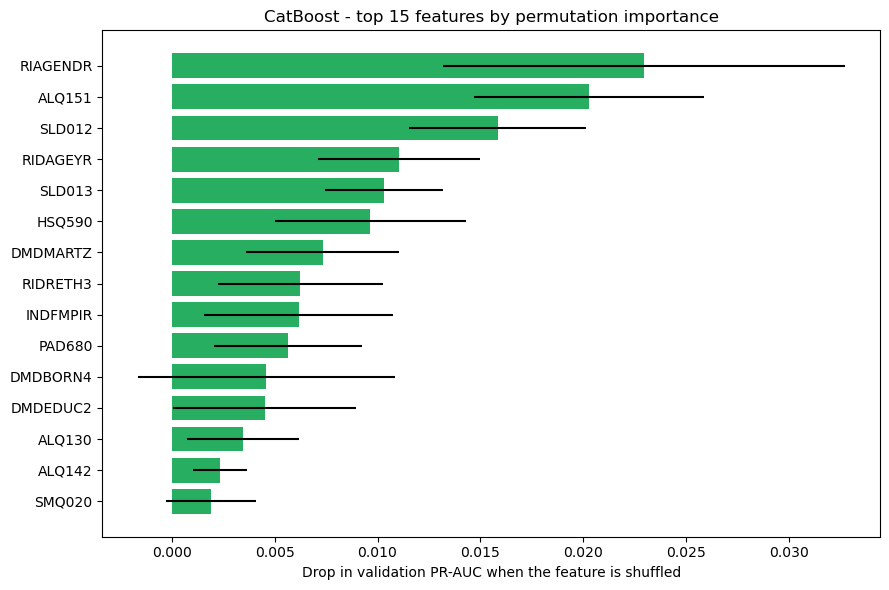

In [19]:
# plotting the 15 most important features
top_importance = importance.head(15).sort_values("Importance_Mean")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top_importance["Feature"],
    top_importance["Importance_Mean"],
    xerr=top_importance["Importance_Std"],
    color="#27ae60",
)
ax.set_xlabel("Drop in validation PR-AUC when the feature is shuffled")
ax.set_title("CatBoost - top 15 features by permutation importance")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "5_1_catboost_permutation_importance.png"), dpi=150)
plt.show()

## 10. Threshold Tuning

> The baseline CatBoost model used the default threshold of 0.50. Since the dataset is imbalanced, I tested different thresholds using the validation set to find the threshold with the best F1 score. The selected threshold will then be used for the final test evaluation. 

In [20]:
# searching the precision-recall curve for the threshold with the best F1 score
def best_f1_threshold(model, X, y):
    proba = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y, proba)

    # the curve returns one more precision/recall point than thresholds, so trim the last one
    precision, recall = precision[:-1], recall[:-1]

    # guarding against a zero denominator when precision and recall are both zero
    denominator = np.where((precision + recall) == 0, 1e-9, precision + recall)
    f1_scores = 2 * precision * recall / denominator

    return float(thresholds[int(np.argmax(f1_scores))])


# tuning the threshold on validation only
catboost_threshold = best_f1_threshold(catboost_model, X_val, y_val)
print(f"CatBoost tuned threshold: {catboost_threshold:.4f}")

CatBoost tuned threshold: 0.5486


## 11. Final Test Evaluation

> The final CatBoost model is evaluated on the test set using the threshold selected from the validation set. The results are used to measure the final performance of the model.

In [21]:
# scoring the winning model on the held-out test set using its tuned threshold
catboost_test = score_model(catboost_model, X_test, y_test, threshold=catboost_threshold)
board.add("CatBoost", "Test", catboost_test)

# showing the full comparison table, PR-AUC first because of class imbalance
results = board.to_frame()
display(results.round(4))

,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,CatBoost,Test,0.2734,0.6817,0.5277,0.2191,0.3096,0.7316,0.5486
1,CatBoost,Validation,0.2461,0.7189,0.6213,0.2089,0.3126,0.6883,0.5000


In [22]:
# printing a confusion matrix and full classification report
def report_model(name, model, X, y, threshold):
    pred = (model.predict_proba(X)[:, 1] >= threshold).astype(int)
    print(f"\n{'=' * 60}\n{name} - test set (threshold {threshold:.3f})\n{'=' * 60}")
    print(pd.DataFrame(
        confusion_matrix(y, pred),
        index=["Actual: No", "Actual: Yes"],
        columns=["Pred: No", "Pred: Yes"],
    ))
    print()
    print(classification_report(y, pred, target_names=["No depression", "Depression"], digits=3))


report_model("CatBoost", catboost_model, X_test, y_test, catboost_threshold)


CatBoost - test set (threshold 0.549)
             Pred: No  Pred: Yes
Actual: No       1383        442
Actual: Yes       111        124

               precision    recall  f1-score   support

No depression      0.926     0.758     0.833      1825
   Depression      0.219     0.528     0.310       235

     accuracy                          0.732      2060
    macro avg      0.572     0.643     0.571      2060
 weighted avg      0.845     0.732     0.774      2060



## 12. Save Model and Results

> The final CatBoost model and results are saved for later use and model comparison. The CatBoost results are also added to the shared scoreboard with the Logistic Regression and Random Forest results.

In [23]:
# persisting the fitted model with its tuned threshold and column order
joblib.dump(
    {
        "model": catboost_model,
        "threshold": catboost_threshold,
        "columns": list(X_train.columns),
        "cat_features": categorical_cols,
        "params": {"depth": best_depth, "learning_rate": best_learning_rate},
    },
    os.path.join(MODEL_DIR, "catboost_seed42.joblib"),
)

# writing the shared scoreboard
final_board = board.save(SCOREBOARD_CSV)

# saving the interpretation table for the written report
importance.to_csv(os.path.join(MODEL_DIR, "catboost_permutation_importance.csv"), index=False)

print("Saved:")
print(f"  {os.path.join(MODEL_DIR, 'catboost_seed42.joblib')}")
print(f"  {SCOREBOARD_CSV}")
display(final_board.round(4))

Saved:
  ../Models/catboost_seed42.joblib
  ../Models/rf_logreg_models_scoreboard.csv


,Model,Split,PR_AUC,ROC_AUC,Recall,Precision,F1,Accuracy,Threshold
0,CatBoost,Test,0.2734,0.6817,0.5277,0.2191,0.3096,0.7316,0.5486
1,CatBoost,Validation,0.2461,0.7189,0.6213,0.2089,0.3126,0.6883,0.5000


Exception ignored in: <function ResourceTracker.__del__ at 0x10f78dd00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10f9e5d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10ce49d00>
Traceback (most recent call last